In [175]:
from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors


In [176]:
df=pd.read_csv("spatial_cluster_practice.csv")

In [177]:
df

,User_ID,Latitude_Coord,Longitude_Coord
0,USER_0000,8.213045,10.984830
1,USER_0001,9.183426,10.166384
2,USER_0002,25.180443,25.771658
3,USER_0003,8.527737,10.693155
4,USER_0004,10.087313,8.285545
...,...,...,...
545,USER_0545,4.648058,34.034950
546,USER_0546,27.061484,33.383066
547,USER_0547,14.514162,-0.610552
548,USER_0548,16.918380,13.175093


In [178]:
X = df[['Latitude_Coord', 'Longitude_Coord']]

In [179]:
print(X)

     Latitude_Coord  Longitude_Coord
0          8.213045        10.984830
1          9.183426        10.166384
2         25.180443        25.771658
3          8.527737        10.693155
4         10.087313         8.285545
..              ...              ...
545        4.648058        34.034950
546       27.061484        33.383066
547       14.514162        -0.610552
548       16.918380        13.175093
549       28.774283        -1.076697

[550 rows x 2 columns]


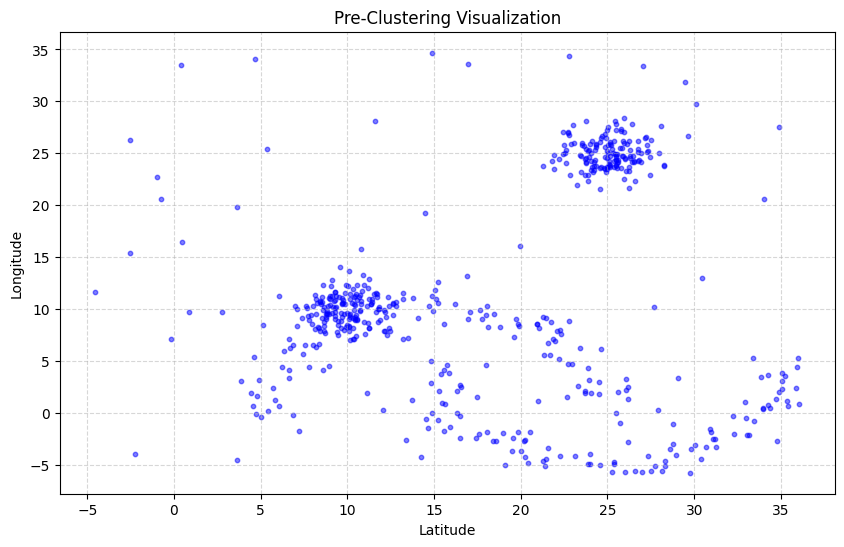

In [180]:
plt.figure(figsize=(10, 6))
# We use the slicing technique we discussed earlier
# Since X is a DataFrame, we use .values to treat it like a NumPy array
plt.scatter(X.values[:, 0], X.values[:, 1], c='blue', s=10, alpha=0.5)

plt.title("Pre-Clustering Visualization")
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

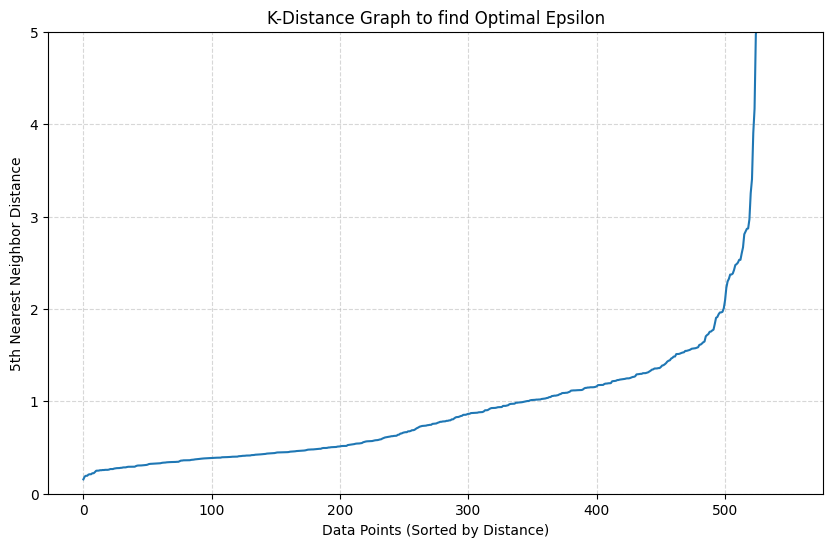

In [181]:
# 1. Calculate distances to the 5th nearest neighbor
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# 2. Sort the distances (ascending)
# We take the distance to the 5th neighbor (index 4)
distances = np.sort(distances[:, 4], axis=0)

# 3. Plot the distances
plt.figure(figsize=(10, 6))
plt.ylim(0, 5)
plt.plot(distances)
plt.title("K-Distance Graph to find Optimal Epsilon")
plt.xlabel("Data Points (Sorted by Distance)")
plt.ylabel("5th Nearest Neighbor Distance")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [182]:
e=1.5
dbscan=DBSCAN(eps=e, min_samples=5)

In [183]:
clusters=dbscan.fit_predict(X)

In [ ]:
# Count the number of clusters (ignoring noise)
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)

print(f'Estimated number of clusters: {n_clusters}')
print(f'Estimated number of noise points: {n_noise} (out of {len(X)} total points)')

Estimated number of clusters: 549
Estimated number of noise points: 53 (out of 550 total points)


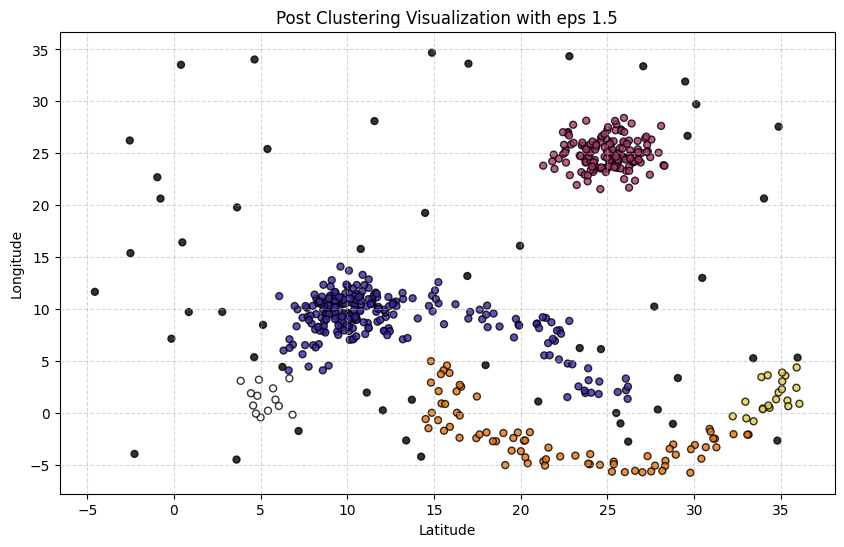

In [186]:
plt.figure(figsize=(10, 6))
# We use the slicing technique we discussed earlier
# Since X is a DataFrame, we use .values to treat it like a NumPy array
plt.scatter(X.values[:, 0], X.values[:, 1], c=clusters,cmap='CMRmap', s=25, alpha=0.8,edgecolors='black')

plt.title("Post Clustering Visualization with eps {}".format(e))
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()